# LED Calib for Commissioning of 2x2 run2


In [1]:
%load_ext autoreload

%autoreload 2

from calibWvfms import *

Don't forget to activate the ndlar-flow venv :)

In [2]:
# # Directory
# # d = '/Users/nsallin/develop/data/2x2/flow/LEDcalib/'
# # /global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_light/cold_commission/v02_LEDscan/mpd_run_calib_rctl_1923.FLOW.hdf5
# data_folder = '/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_light/cold_commission/v02_LEDscan/'

# # File
# # f = 'mpd_run_calib_rctl_1923.FLOW.hdf5'


# run_summary = '20251008_200916_run_summary.json'

# # Output
# o ='/global/homes/s/sallinn/data/2x2_calib/test/LEDcalib_run2'

In [3]:
# Load the file
# wvfms = calibWvfms(filedir = data_folder, filename = f, output_path=o, log_level='DEBUG')

In [4]:
import json

def get_subruns_and_channels(json_path):
    """
    Extract 'data_file', 'subrun' and 'active_chans' values from a JSON file.

    Parameters:
        json_path (str): Path to the JSON file.

    Returns:
    subruns_info (list): subrun infos of the type [[data_file, subrun_number, active_chans], ...] with
            - data_file (str): path to data file
            - subrun_number (int): subrun number
            - active_chans (list) : list of active chans of the type [[adcA, chanB], [adcX, chanY], ...]

    """
    with open(json_path, "r") as f:
        run_info = json.load(f)

    subruns_info = []

    if "subruns" in run_info:
        for subrun in run_info["subruns"]:
            # print(subrun)
            data_file = subrun["data_file"]
            subrun_number = subrun["subrun"]
            active_chans = subrun["active_chans"]

            subruns_info.append([data_file, subrun_number, active_chans])
    else:
        raise KeyError(f"'subruns' key not found in {json_path}")

    return subruns_info

In [5]:
# run_info = get_subruns_and_channels(run_summary)

# subrun = 0

# active_chans = run_info[subrun][2]

# # print("~~~~~~~~~~~~ run ~~~~~~~~~~~~")
# # print(f"file  :{}")

# print("~~~~~~~~~~~~ subrun ~~~~~~~~~~~~")
# print(f"file  :{run_info[subrun][0]}")
# print(f"subrun  :{run_info[subrun][1]}")
# print(f"active_chans ({len(active_chans)}): {active_chans}")

In [6]:
import matplotlib.pyplot as plt

def title_page(text, output):
    # Create a figure with a black background
    fig, ax = plt.subplots(figsize=(6, 4))
    # ax.set_facecolor('black')

    # Add centered white text
    ax.text(0.5, 0.5, text, color='black',
            fontsize=24, ha='center', va='center')

    # Remove axes
    ax.axis('off')

    # Save to PDF
    
    output.savefig()
    plt.close()

In [7]:
import os

def calibrate_sipm(wvfms, subrun_info):
    """
        Function to run through the calibration chain 
            1. Compute the fingerplots
            # 2. Fit the fingerplots
            # 3. Compute the gain
            # 4. Print out the result in a summary pdf

        Summary pdf is made of:
            - 10 waveforms (equally spaced between the first and last events)
            - the fingerplot
            # - the fingerplot with the inital guess and the fitted funciton
            - the wvfms that didnt't make the "int extrem value cut"
    """
    # ~~~~~~~~~~~~~~~~~~ Define general constants ~~~~~~~~~~~~~~~~~~
    signal_window = [60,90] # [ticks]
    Nevents = 19_000

    active_chans = subrun_info[2]
    # ~~~~~~~~~~~~~~~~~~ Loop over the adc and chan (w.r.t the run summary) ~~~~~~~~~~~~~~~~~~
    for adc, chan in active_chans:

        # if adc not in [0, 1]  :
        #     continue

        # adc = 4   #DEBUG
        # chan = 13

        output_dir = os.path.join(wvfms.output_path, f"adc{adc}/chan{chan}")
        os.makedirs(output_dir, exist_ok=True)
        output_pdf = os.path.join(output_dir, f"adc{adc}_chan{chan}_calib_summary.pdf")

        # Output file
        with PdfPages(output_pdf) as summary_pdf:


            print(f" adc: {adc}, chan: {chan}") # DEBUG

            # ~~~~~~~~~~~~~~~~~~ Compute the fingerplot ~~~~~~~~~~~~~~~~~~
            wvfms.compute_fingerplots(Nevent=Nevents, adcs=adc, chans=chan, int_window=signal_window, Nbins=110, mode='integral', nSig=5)
            # Save in output pdf
            title_page("Finger plot",summary_pdf)
            plot_fingerplot(*wvfms.fingerplots[adc][chan], title=f'Fingerplot of ADC {adc}, chan. {chan}', output=summary_pdf)# show=True, plot_name=f'fingerplot_ADC{adc}_chan{chan}.png')

            # ~~~~~~~~~~~~~~~~~~ Fit the fingerplot ~~~~~~~~~~~~~~~~~~
            title_page("Finger plot with p0",summary_pdf)
            wvfms.fit_fingerplots(adc, chan, output=summary_pdf)
            if wvfms.fit_status[adc][chan] == 2:
                # Print some waveforms for examples
                title_page("No initial guess found\nWvfms Examples",summary_pdf)
                Nwvfms = 10
                for event in range(0, Nevents, int(Nevents/Nwvfms)):
                    wvfms.plot_wvfm(event=event, adc=adc, chan=chan, xlim=None, verbose=False, baseline=None, show_plot=False, output=summary_pdf, integral=signal_window)#, peakFinder=False, minWidth=5, cut_offset=0, min_peak_distance=None)
                continue

            # ~~~~~~~~~~~~~~~~~~ Compute the gain ~~~~~~~~~~~~~~~~~~
            wvfms.compute_gains(adcs=adc, chans=chan)

            # Save in output pdf
            title_page("Finger plot with\nfitted function and gain",summary_pdf)
            # print(f" in notebook: adc: {adc}, chan: {chan}, status: {wvfms.fit_status[adc][chan]}") # DEBUG
            plot_fingerplot(*wvfms.fingerplots[adc][chan], title=f'Fingerplot of ADC {adc}, chan. {chan} with fitted function', fit_xlim=wvfms.fit_lim[adc][chan], fit_params=wvfms.fitted_params[adc][chan], output=summary_pdf, fit_status=wvfms.fit_status[adc][chan], reduced_chi_squared=wvfms.reduced_chi_squared[adc][chan], gain=wvfms.gains[adc][chan])
            



            # ~~~~~~~~~~~~~~~~~~ Print out summary ~~~~~~~~~~~~~~~~~~

            # Print some waveforms for examples
            title_page("Wvfms Examples",summary_pdf)
            Nwvfms = 10
            for event in range(0, Nevents, int(Nevents/Nwvfms)):
                wvfms.plot_wvfm(event=event, adc=adc, chan=chan, xlim=None, verbose=False, baseline=None, show_plot=False, output=summary_pdf, integral=signal_window)#, peakFinder=False, minWidth=5, cut_offset=0, min_peak_distance=None)


            # Extrem waveforms
            title_page("Cutout waveforms Examples:\n(Integral more than\n5 sig from mean integral value)",summary_pdf)
            # print(f" extrem events: {wvfms.extrem_Int_val[adc][chan]}")
            for event in wvfms.extrem_Int_val[adc][chan]:
                wvfms.plot_wvfm(event=event, adc=adc, chan=chan, xlim=None, verbose=False, baseline=None, show_plot=False, output=summary_pdf, integral=signal_window)#, peakFinder=False, minWidth=5, cut_offset=0, min_peak_distance=None)
    
        # break # DEBUG
    print('~~~~~~~~~~~~ FINISHED ~~~~~~~~~~')



In [8]:
# calibrate_sipm(wvfms)

In [9]:
def get_flowed_data(raw_data):
    """
    Extract the filename (without extension) from a full file path.
    Example:
        /path/to/mpd_run_calib_rctl_1923.data → mpd_run_calib_rctl_1923
    """
    raw_filename = os.path.basename(raw_data)       # → 'mpd_run_calib_rctl_1923.data'
    name, _ = os.path.splitext(raw_filename)    # → ('mpd_run_calib_rctl_1923', '.data')

    data_filename = f"{name}.FLOW.hdf5"
    return data_filename

# RUN quick for module 0 and the others

In [ ]:
# Directory
run_summary_folder = '/global/homes/s/sallinn/data/2x2_calib/test/LEDcalib_run2/'
data_folder = '/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_light/cold_commission/v03_LEDscan/'

run_summary = '20251015_201938_run_summary.json'

# Output

output ='/global/homes/s/sallinn/data/2x2_calib/test/20251015_LEDcalib_run2'

In [11]:
# Load the file
# wvfms = calibWvfms(filedir = data_folder, filename = f, output_path=o, log_level='DEBUG')

In [ ]:
run_info = get_subruns_and_channels(os.path.join(run_summary_folder,run_summary))

# subrun = 0

# active_chans = run_info[subrun][2]

print("~~~~~~~~~~~~ subrun 0 ~~~~~~~~~~~~")
# print(f"file  :{}")

subrun = run_info[0]
data_file = get_flowed_data(subrun[0])
wvfms = calibWvfms(filedir = data_folder, filename = data_file, output_path=output, log_level='DEBUG')
calibrate_sipm(wvfms, subrun)


for subrun in run_info[1:]:
    print(f"~~~~~~~~~~~~ subrun {subrun[1]} ~~~~~~~~~~~~")
    print(subrun)
    data_file = get_flowed_data(subrun[0])
    # print(data_file)
    wvfms.load_file(filedir = data_folder, filename = data_file)
    calibrate_sipm(wvfms, subrun)

2025-10-14 11:09:09,273 - INFO - set_log_level - Log level changed to DEBUG


~~~~~~~~~~~~ subrun 0 ~~~~~~~~~~~~


2025-10-14 11:09:23,925 - INFO - __init__ - Processing file /global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_light/cold_commission/v02_LEDscan/mpd_run_calib_rctl_1923.FLOW.hdf5
2025-10-14 11:09:23,928 - INFO - __init__ - The output path is set to /global/homes/s/sallinn/data/2x2_calib/test/LEDcalib_run2
2025-10-14 11:09:23,928 - INFO - __init__ - Number of events in the selection: 19912
2025-10-14 11:09:23,930 - DEBUG - compute_fingerplots - Computing the fingerplots of the file mpd_run_calib_rctl_1923.FLOW.hdf5 with 19000 events
2025-10-14 11:09:23,931 - DEBUG - compute_fingerplots - ADCs: [0]
2025-10-14 11:09:23,932 - DEBUG - compute_fingerplots - Chans: [4]
2025-10-14 11:09:23,974 - INFO - compute_fingerplots - The finger plots were computed with 19000 events in mode "integral"
2025-10-14 11:09:24,076 - DEBUG - plot_fingerplot - Plotting the finger plot


 adc: 0, chan: 4
shape: (19100,)


2025-10-14 11:09:24,239 - DEBUG - fit_fingerplots - Fitting the fingerplots of the file mpd_run_calib_rctl_1923.FLOW.hdf5
2025-10-14 11:09:24,240 - DEBUG - fit_fingerplots - ADCs: [0]
2025-10-14 11:09:24,240 - DEBUG - fit_fingerplots - Chans: [4]
2025-10-14 11:09:24,241 - DEBUG - fit_fingerplots - Compute fingerplots p0 of ADC 0, chan. 4
2025-10-14 11:09:24,247 - DEBUG - plot_fingerplot - Plotting the finger plot


...




status: 0


2025-10-14 11:31:51,115 - DEBUG - compute_fingerplots - Computing the fingerplots of the file mpd_run_calib_rctl_1941.FLOW.hdf5 with 19000 events
2025-10-14 11:31:51,116 - DEBUG - compute_fingerplots - ADCs: [5]
2025-10-14 11:31:51,117 - DEBUG - compute_fingerplots - Chans: [57]
2025-10-14 11:31:51,119 - INFO - compute_fingerplots - The finger plots were computed with 19000 events in mode "integral"
2025-10-14 11:31:51,136 - DEBUG - plot_fingerplot - Plotting the finger plot
2025-10-14 11:31:51,276 - DEBUG - fit_fingerplots - Fitting the fingerplots of the file mpd_run_calib_rctl_1941.FLOW.hdf5
2025-10-14 11:31:51,277 - DEBUG - fit_fingerplots - ADCs: [5]
2025-10-14 11:31:51,277 - DEBUG - fit_fingerplots - Chans: [57]
2025-10-14 11:31:51,278 - DEBUG - fit_fingerplots - Compute fingerplots p0 of ADC 5, chan. 57
2025-10-14 11:31:51,279 - DEBUG - plot_fingerplot - Plotting the finger plot


 adc: 5, chan: 57
shape: (19100,)
fit_bounds: [[ 4.81650000e+02 -8.32391200e+05  2.02427857e+02  6.00000000e-01
  -8.31856800e+05  2.02427857e+02  9.24350000e+02 -8.30520800e+05
   2.49483454e+02  7.02000000e+01 -8.29719200e+05  2.49483454e+02
   1.15425000e+03 -8.28383200e+05  2.80262631e+02  1.26600000e+02
  -8.27581600e+05  2.80262631e+02  1.12385000e+03 -8.26245600e+05
   2.72620681e+02  1.67400000e+02 -8.25444000e+05  2.72620681e+02
   7.04900000e+02 -8.24108000e+05  3.42445429e+02  1.92600000e+02
  -8.23573600e+05  3.42445429e+02  4.39850000e+02 -8.22237600e+05
   3.48070166e+02  1.40400000e+02 -8.21436000e+05  3.48070166e+02
   2.58400000e+02 -8.20100000e+05  3.28663429e+02  9.30000000e+01
  -8.19298400e+05  3.28663429e+02]
 [ 5.58700000e+02 -8.31856800e+05  5.07069643e+02  2.10000000e+00
  -8.31055200e+05  1.26617411e+03  1.07130000e+03 -8.29986400e+05
   6.24708635e+02  1.29700000e+02 -8.28917600e+05  1.56027159e+03
   1.33750000e+03 -8.27848800e+05  7.01656577e+02  2.33100000

2025-10-14 11:31:51,538 - DEBUG - fit_fingerplots - Fingerplots of ADC 5, chan. 57 fitted
2025-10-14 11:31:51,538 - INFO - fit_fingerplots - The fingerplots of the file mpd_run_calib_rctl_1941.FLOW.hdf5 were fitted.
2025-10-14 11:31:51,582 - DEBUG - plot_fingerplot - Plotting the finger plot





status: 0
~~~~~~~~~~~~ FINISHED ~~~~~~~~~~


In [13]:
def plot_gain(gains):
    Nadcs, Nchans = gains.shape

    fig_gains, axs_gains = plt.subplots(nrows = 8, ncols=1, sharex='row', figsize=[12.8, 24])

    

    # colors=['red', 'blue', 'green', 'magenta']

    for adc, ax_gain in enumerate(axs_gains):
        ax_gain.set_xlabel('channel')
        ax_gain.set_ylabel('Gain [ADC counts]')
        ax_gain.grid(True)
        chans = np.arange(Nchans)   
        ax_gain.set_title(f"ADC: {adc}") 
        ax_gain.plot(chans, gains[adc], marker='.', ls='')
        ax_gain.set_xticks(np.arange(0, Nchans, 2))

    plt.tight_layout(pad=2.0)
                
    return 0


0

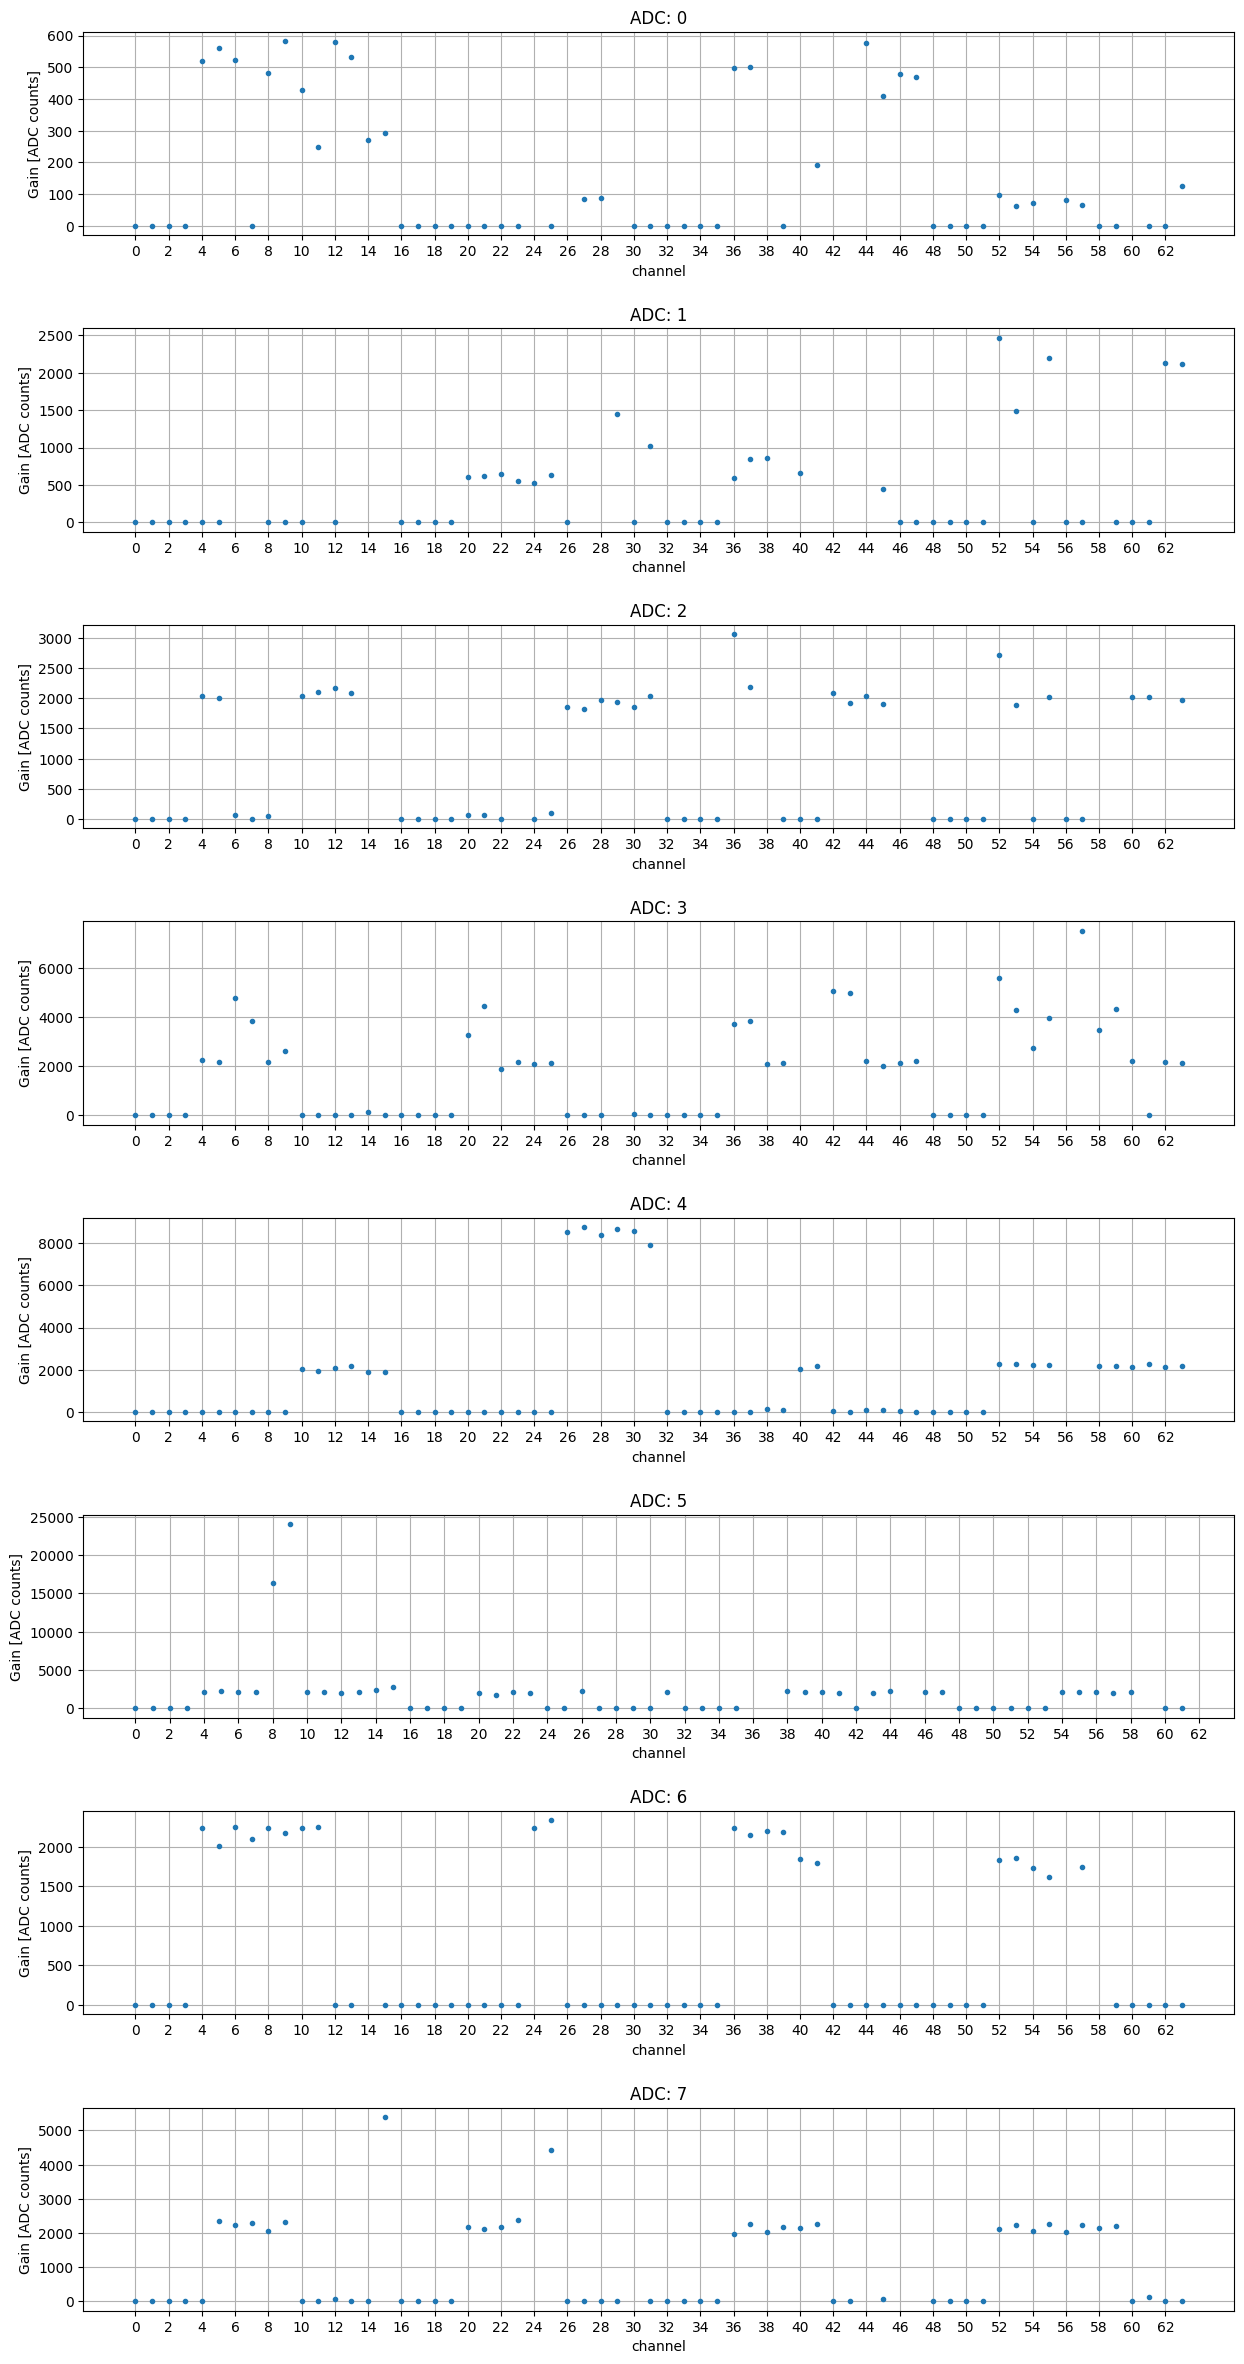

In [14]:
plot_gain(wvfms.gains)
